**Experiment 1:**

**Aim:** Implement linear regression with one variable on the California Housing dataset to predict
housing prices based on a single feature (e.g., the average number of rooms per dwelling).
Tasks:


1.   Load and preprocess the datase.
2.   Implement linear regression using both gradient descent and the normal equation.
1.   Evaluate the model performance using metrics such as Mean Squared Error (MSE) and R-squared.
2.   Visualize the fitted line along with the data points.

# **Demo of Linear Regression using small data**

**Can a Computer Find a Pattern?**

| Hours Studied | Marks |
| ------------- | ----: |
| 1             |    40 |
| 2             |    50 |
| 3             |    58 |
| 4             |    70 |
| 5             |    82 |
| 6             |    90 |

If a student studies 7 hours, what marks might they get?

In [ ]:
import pandas as pd

data = {
    "Hours":[1,2,3,4,5,6],
    "Marks":[40,50,58,70,82,90]
}

df=pd.DataFrame(data)
df

,Hours,Marks
0,1,40
1,2,50
2,3,58
3,4,70
4,5,82
5,6,90


**Visualizing the Data**

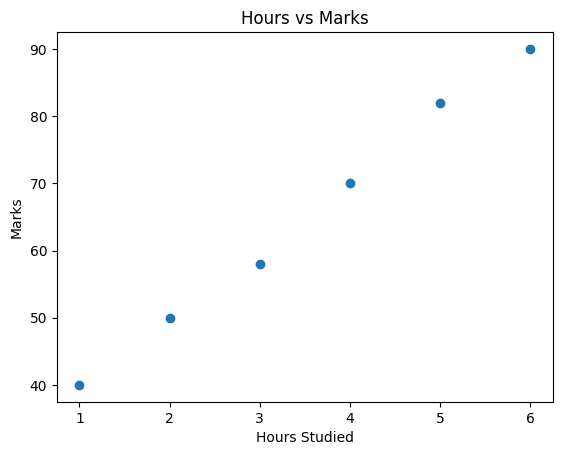

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["Hours"],df["Marks"])
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Hours vs Marks")
plt.show()

**What is the Best Line?**

Equation for a Line: Y = Mx + C
x:no.of hours
M: Slope
C: Intercept

Trails:
1. M = 10, C= 20
2. M = 11, C = 30
3. M = 8, C = 28

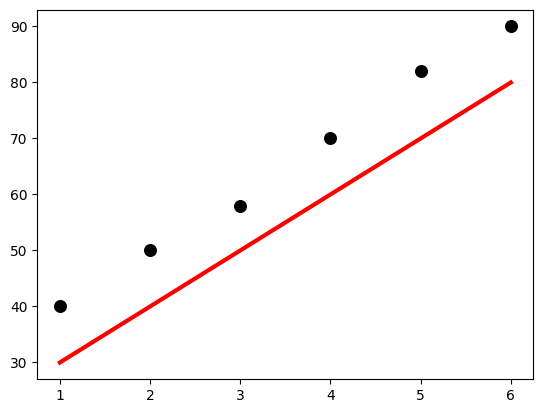

In [ ]:
plt.figure()

# Scatter plot
plt.scatter(df["Hours"], df["Marks"],
            color="black",
            s=70,
            label="Actual Data")

x = df["Hours"]
y_line = 10*x + 20

plt.plot(x,
         y_line,
         color="red",
         linewidth=3,
         label="Line 1")

In [ ]:
#Calculate predictions using line 1 and adding to the dataframe

df["Prediction"]=10*df["Hours"]+20

In [ ]:
df

,Hours,Marks,Prediction
0,1,40,30
1,2,50,40
2,3,58,50
3,4,70,60
4,5,82,70
5,6,90,80


In [ ]:
#Calculate error in predictions

df["Error"]=df["Marks"]-df["Prediction"]
df

,Hours,Marks,Prediction,Error
0,1,40,30,10
1,2,50,40,10
2,3,58,50,8
3,4,70,60,10
4,5,82,70,12
5,6,90,80,10


**Mean Squared Error (MSE)**

In [ ]:
df["Squared Error"]=df["Error"]**2
print(df)
df["Squared Error"].mean()

   Hours  Marks  Prediction  Error  Squared Error
0      1     40          30     10            100
1      2     50          40     10            100
2      3     58          50      8             64
3      4     70          60     10            100
4      5     82          70     12            144
5      6     90          80     10            100


np.float64(101.33333333333333)

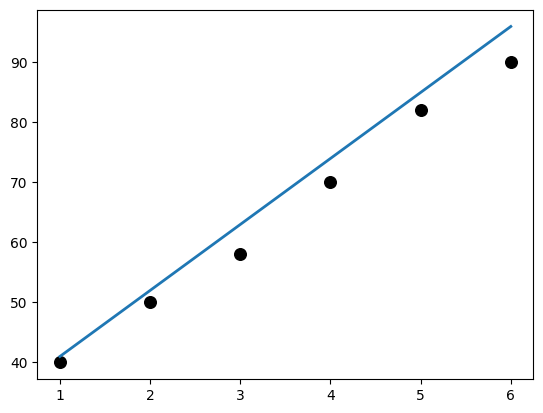

In [ ]:
#Try to improve the line - Line 2

plt.figure()

# Scatter plot
plt.scatter(df["Hours"], df["Marks"],
            color="black",
            s=70,
            label="Actual Data")
# Line 2
plt.plot(x, 11*x+30,
         label="Line 2",
         linewidth=2)

In [ ]:
#Calculation of predictions using Line 2
df["Prediction"]=11*df["Hours"]+30

#Calculation of Error
df["Error"]=df["Marks"]-df["Prediction"]
df["Squared Error"]=df["Error"]**2
print(df)
df["Squared Error"].mean()

   Hours  Marks  Prediction  Error  Squared Error
0      1     40          41     -1              1
1      2     50          52     -2              4
2      3     58          63     -5             25
3      4     70          74     -4             16
4      5     82          85     -3              9
5      6     90          96     -6             36


np.float64(15.166666666666666)

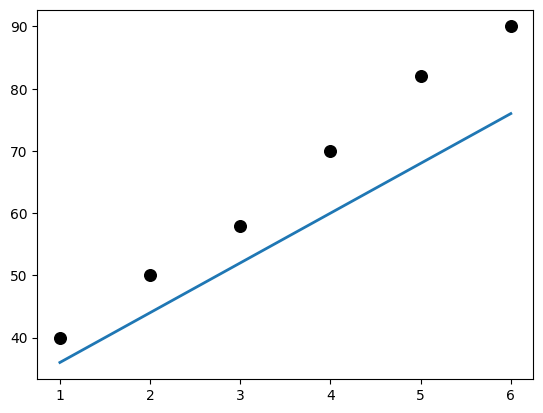

In [ ]:
#Try to improve the line - Line 3

plt.figure()

# Scatter plot
plt.scatter(df["Hours"], df["Marks"],
            color="black",
            s=70,
            label="Actual Data")

x = df["Hours"]

# Line 3
plt.plot(x, 8*x+28,
         label="Line 3",
         linewidth=2)

In [ ]:
#Calculation of predictions using Line 2
df["Prediction"]=8*df["Hours"]+28

#Calculation of Error
df["Error"]=df["Marks"]-df["Prediction"]
df["Squared Error"]=df["Error"]**2
print(df)
df["Squared Error"].mean()

   Hours  Marks  Prediction  Error  Squared Error
0      1     40          36      4             16
1      2     50          44      6             36
2      3     58          52      6             36
3      4     70          60     10            100
4      5     82          68     14            196
5      6     90          76     14            196


np.float64(96.66666666666667)

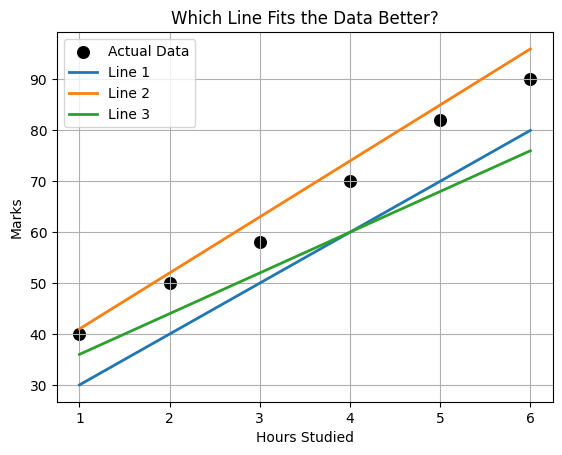

In [ ]:
#Vislaizing our three trials in a single figure

plt.figure()

# Scatter plot
plt.scatter(df["Hours"], df["Marks"],
            color="black",
            s=70,
            label="Actual Data")

x = df["Hours"]

# Line 1
plt.plot(x, 10*x+20,
         label="Line 1",
         linewidth=2)

# Line 2
plt.plot(x, 11*x+30,
         label="Line 2",
         linewidth=2)

# Line 3
plt.plot(x, 8*x+28,
         label="Line 3",
         linewidth=2)


plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.title("Which Line Fits the Data Better?")
plt.legend()
plt.grid(True)

plt.show()

# **Using Scikit-Learn**

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

In [ ]:
from sklearn.linear_model import LinearRegression

X=df[["Hours"]]
y=df["Marks"]
model=LinearRegression()
model.fit(X,y)
print(model.coef_)
print(model.intercept_)

[10.22857143]
29.199999999999996


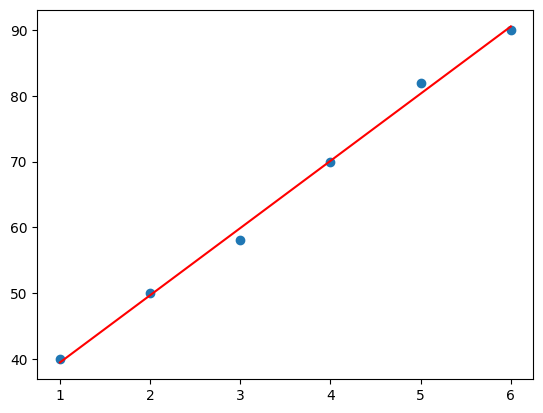

In [ ]:
pred=model.predict(X)

plt.scatter(X,y)

plt.plot(X,pred,color="red")

plt.show()

https://scikit-learn.org/stable/api/sklearn.metrics.html

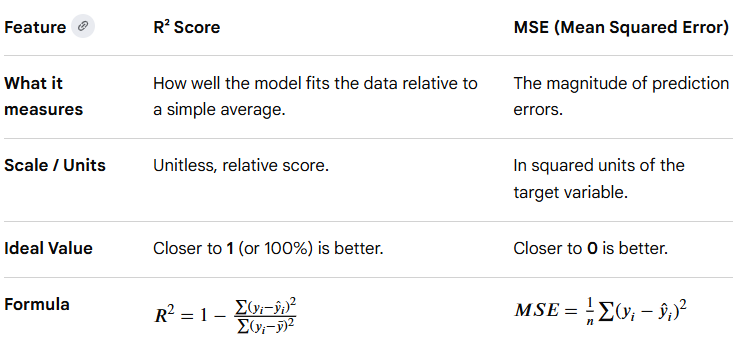

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

print(mean_squared_error(y,pred))

print(r2_score(y,pred))

1.180952380952385
0.9961448779729519


**Gradient Descent in Linear Regression**

Gradient Descent is an optimization algorithm used in linear regression to find the best-fit line by minimizing prediction error. It works by repeatedly adjusting the model parameters based on the direction of the steepest decrease in the cost function. This iterative approach helps the model converge toward the optimal solution.

Reduces prediction error by minimizing the cost function, typically Mean Squared Error (MSE).
Efficiently finds optimal model parameters, especially for large datasets and high-dimensional data.

https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html

Slope = 10.341156478350117
Intercept = 28.91306987591062
Linear Regression MSE
1.180952380952385

Gradient Descent MSE
1.2293964480143977


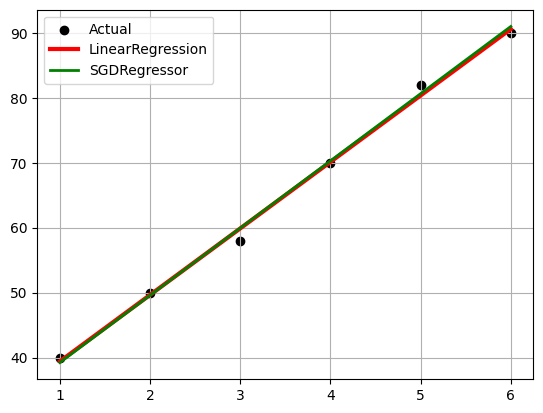

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import SGDRegressor
sgd=SGDRegressor(max_iter=10000,
                 learning_rate="constant",
                 eta0=0.01,
                 random_state=42)

sgd.fit(X,y)
print("Slope =",sgd.coef_[0])

print("Intercept =",sgd.intercept_[0])
sgd_pred=sgd.predict(X)

print("Linear Regression MSE")

print(mean_squared_error(y,pred))

print()

print("Gradient Descent MSE")

print(mean_squared_error(y,sgd_pred))

plt.scatter(X,y,color="black",label="Actual")

plt.plot(X,pred,color="red",
         linewidth=3,
         label="LinearRegression")

plt.plot(X,
         sgd_pred,
         color="green",
         linewidth=2,
         label="SGDRegressor")

plt.legend()

plt.grid()

plt.show()

# **From Simple Data to California Housing Dataset**

In [1]:
from sklearn.datasets import fetch_california_housing

housing=fetch_california_housing(as_frame=True)

housing_df=housing.frame

housing_df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [2]:
#Selection the features and label

X=housing_df[["AveRooms"]]

y=housing_df["MedHouseVal"]

**Train Test Split Using Sklearn**
The train_test_split() method is used to split our data into train and test sets.

First, we need to divide our data into features (X) and labels (y). The dataframe gets divided into X_train,X_test , y_train and y_test. X_train and y_train sets are used for training and fitting the model. The X_test and y_test sets are used for testing the model if it's predicting the right outputs/labels. we can explicitly test the size of the train and test sets. It is suggested to keep our train sets larger than the test sets.

*   Train set: The training dataset is a set of data that was utilized to fit the model. The dataset on which the model is trained. This data is seen and learned by the model.
*   Test set: The test dataset is a subset of the training dataset that is utilized to give an accurate evaluation of a final model fit.

*   validation set:  A validation dataset is a sample of data from your model's training set that is used to estimate model performance while tuning the model's hyperparameters.

In [3]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [4]:
X_train.shape, X_test.shape

((16512, 1), (4128, 1))

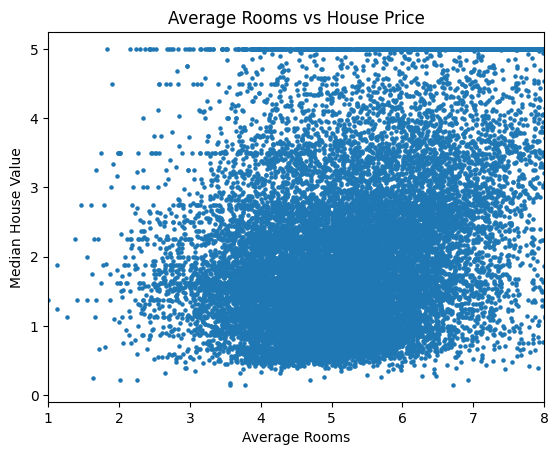

In [6]:
#Visualizing the data
import matplotlib.pyplot as plt
plt.scatter(X,y,s=5)

plt.xlabel("Average Rooms")
plt.xlim(1,8)

plt.ylabel("Median House Value")

plt.title("Average Rooms vs House Price")

plt.show()

In [1]:
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import SGDRegressor, LinearRegression

model=LinearRegression()
model.fit(X_train,y_train)

print(model.coef_)
print(model.intercept_)

NameError: name 'X_train' is not defined

In [8]:
y_pred=model.predict(X_test)

mse=mean_squared_error(y_test,y_pred)
print(mse)

r2=r2_score(y_test,y_pred)
print(r2)

1.2923314440807299
0.013795337532284901


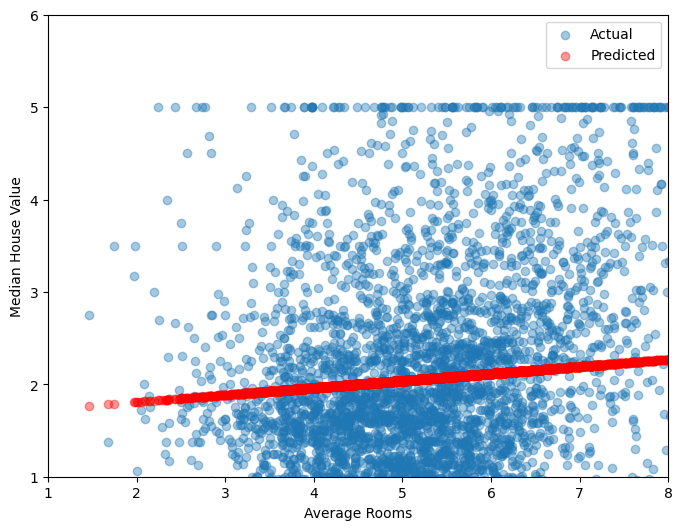

In [9]:
plt.figure(figsize=(8,6))

plt.scatter(X_test,
            y_test,
            alpha=0.4,
            label="Actual")

plt.scatter(X_test,
            y_pred,
            color="red",
            alpha=0.4,
            label="Predicted")

plt.xlabel("Average Rooms")
plt.xlim(1,8)

plt.ylabel("Median House Value")
plt.ylim(1,6)

plt.legend()

plt.show()